In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Image

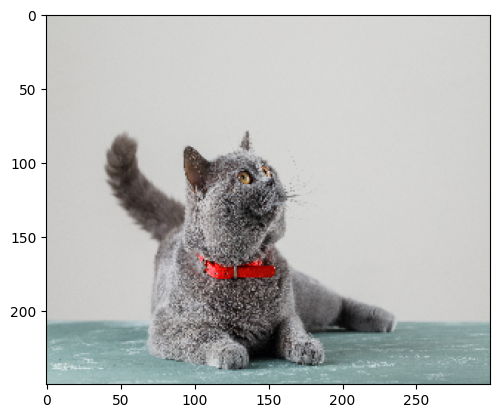

In [2]:
image_path = "images/grey-cat.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (300, 250))
plt.imshow(image)

## Ground Truth and Predicted Bounding Boxes

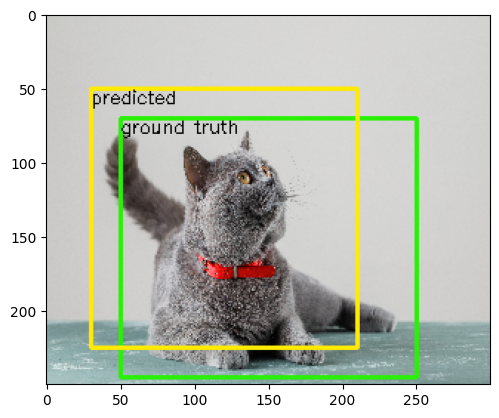

In [3]:
# ground truth and predicted box
ground_truth_box = (50, 70, 200, 175)
prediction_box = (30, 50, 180, 175)

# draw boxes
x, y, w, h = ground_truth_box
cv2.rectangle(image, (x,y), (x+w, y+h), (42, 240, 7), 2)
# cv2.putText(image, text, org, font, fontScale, color, thickness=1, lineType=cv2.LINE_8, bottomLeftOrigin=False)
cv2.putText(image, "ground truth", (x,y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

x, y, w, h = prediction_box
cv2.rectangle(image, (x, y), (x+w, y+h), (255, 234, 0), 2)
cv2.putText(image, "predicted", (x, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

plt.imshow(image)

## Intersection Over Union

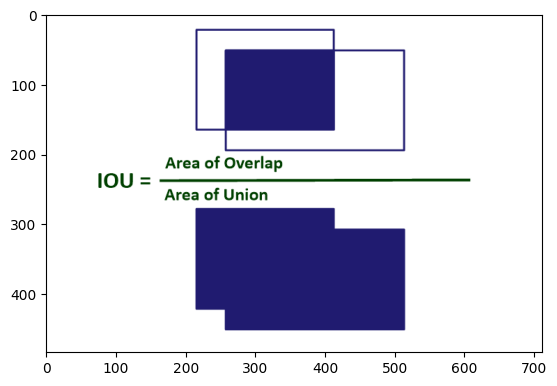

In [4]:
iou = cv2.imread("images/iou.png")
iou = cv2.cvtColor(iou, cv2.COLOR_BGR2RGB)
plt.imshow(iou)

In [5]:
# box coordinates
gt_x1, gt_y1 = ground_truth_box[0] , ground_truth_box[1]
gt_x2, gt_y2 = ground_truth_box[0] + ground_truth_box[2], ground_truth_box[1] + ground_truth_box[3]
p_x1, p_y1 = prediction_box[0] , prediction_box[1]
p_x2, p_y2 = prediction_box[0] + prediction_box[2], prediction_box[1] + prediction_box[3]

In [6]:
# intersection points
inter_x1 = max(gt_x1, p_x1)
inter_y1 = max(gt_y1, p_y1)
inter_x2 = min(gt_x2, p_x2)
inter_y2 = min(gt_y2, p_y2)

intersection area:  24800


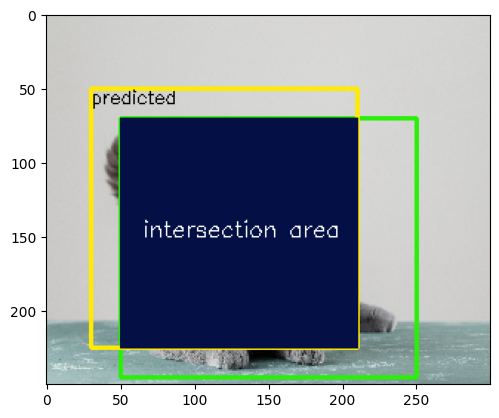

In [7]:
# intersection area
inter_w = max(0, inter_x2 - inter_x1)
inter_h = max(0, inter_y2 - inter_y1)
intersection_area = inter_w * inter_h
print("intersection area: ", intersection_area)

# intersection area
cv2.rectangle(image, (inter_x1, inter_y1), (inter_x2, inter_y2), (3, 15, 69), -1)
cv2.putText(image, "intersection area", (inter_x1+15, inter_y1+80), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
plt.imshow(image)

ground truth box area:  35000
prediction box area:  31500
union area:  41700


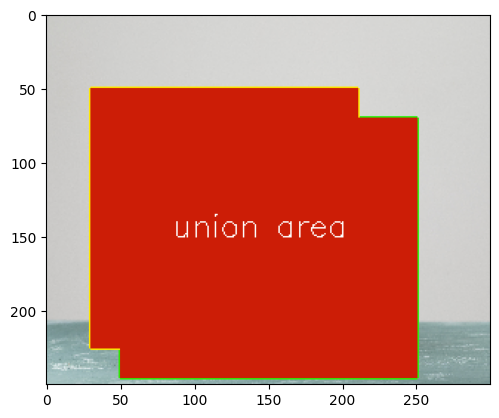

In [8]:
# union area
gt_area = ground_truth_box[2] * ground_truth_box[3]
p_area = prediction_box[2] * prediction_box[3]
print("ground truth box area: ", gt_area)
print("prediction box area: ", p_area)
union_area = gt_area + p_area - intersection_area
print("union area: ", union_area)

# union area visualization
cv2.rectangle(image, (gt_x1, gt_y1), (gt_x2, gt_y2), (204, 29, 6), -1) # gt_bx
cv2.rectangle(image, (p_x1, p_y1), (p_x2, p_y2), (204, 29, 6), -1) # p_box
cv2.putText(image, "union area", (p_x1+55, p_y1+100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1)
plt.imshow(image)

In [9]:
# iou
iou = intersection_area / union_area if union_area > 0 else 0
print(iou)

0.5947242206235012
